In [1]:
import pandas as pd
import numpy as np 
from mlxtend.plotting import plot_decision_regions

In [4]:
df = pd.DataFrame()

In [5]:
df['X1'] = [1,2,3,4,5,6,7,6,9,9]
df['X2'] = [2,4,5,6,7,8,94,3,4,1]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [6]:
df

,X1,X2,label
0,1,2,1
1,2,4,1
2,3,5,0
3,4,6,1
4,5,7,0
5,6,8,1
6,7,94,0
7,6,3,1
8,9,4,0
9,9,1,0


<Axes: xlabel='X1', ylabel='X2'>

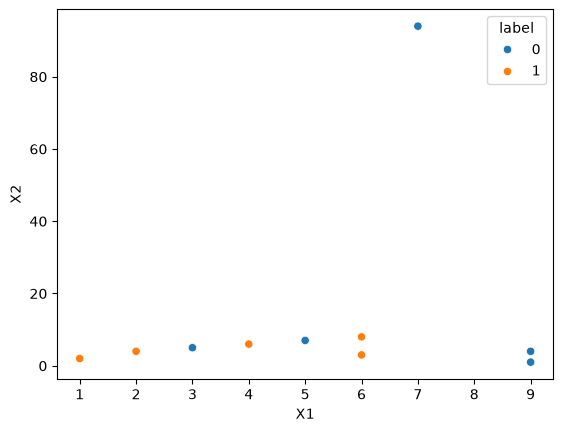

In [7]:
import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [8]:
df['weights'] = 1/df.shape[0]

In [9]:
df

,X1,X2,label,weights
0,1,2,1,0.1
1,2,4,1,0.1
2,3,5,0,0.1
3,4,6,1,0.1
4,5,7,0,0.1
5,6,8,1,0.1
6,7,94,0,0.1
7,6,3,1,0.1
8,9,4,0,0.1
9,9,1,0,0.1


In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [12]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [ ]:
# Train 1st model
dt1.fit(X,y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.5, 0.75, 'x[0] <= 6.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

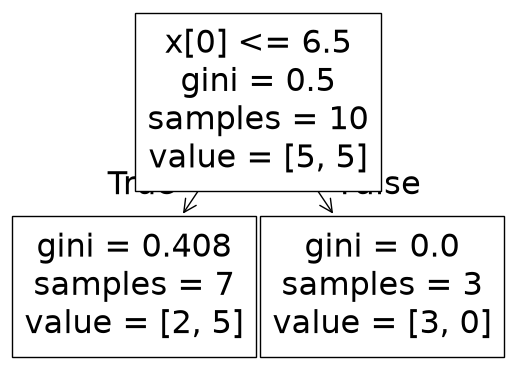

In [14]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

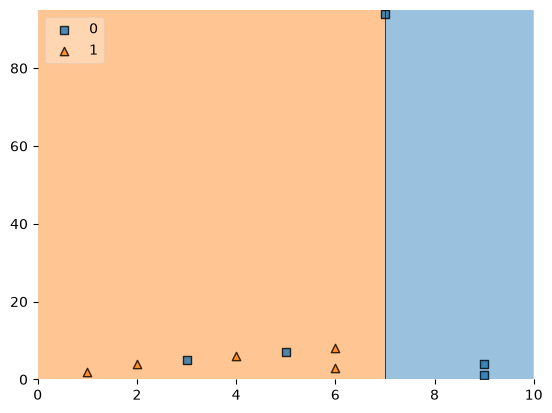

In [15]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [16]:
df['y_pred'] = dt1.predict(X)

In [17]:
df

,X1,X2,label,weights,y_pred
0,1,2,1,0.1,1
1,2,4,1,0.1,1
2,3,5,0,0.1,1
3,4,6,1,0.1,1
4,5,7,0,0.1,1
5,6,8,1,0.1,1
6,7,94,0,0.1,0
7,6,3,1,0.1,1
8,9,4,0,0.1,0
9,9,1,0,0.1,0


In [18]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [19]:
# calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [20]:
# Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [21]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [22]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,2,1,0.1,1,0.065508
1,2,4,1,0.1,1,0.065508
2,3,5,0,0.1,1,0.152653
3,4,6,1,0.1,1,0.065508
4,5,7,0,0.1,1,0.152653
5,6,8,1,0.1,1,0.065508
6,7,94,0,0.1,0,0.065508
7,6,3,1,0.1,1,0.065508
8,9,4,0,0.1,0,0.065508
9,9,1,0,0.1,0,0.065508


In [23]:
df['updated_weights'].sum()

np.float64(0.8293697656827363)

In [24]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [25]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,2,1,0.1,1,0.065508,0.078985
1,2,4,1,0.1,1,0.065508,0.078985
2,3,5,0,0.1,1,0.152653,0.184060
3,4,6,1,0.1,1,0.065508,0.078985
4,5,7,0,0.1,1,0.152653,0.184060
5,6,8,1,0.1,1,0.065508,0.078985
6,7,94,0,0.1,0,0.065508,0.078985
7,6,3,1,0.1,1,0.065508,0.078985
8,9,4,0,0.1,0,0.065508,0.078985
9,9,1,0,0.1,0,0.065508,0.078985


In [26]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [27]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [28]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,2,1,0.1,1,0.065508,0.000000,0.078985
1,2,4,1,0.1,1,0.065508,0.078985,0.157970
2,3,5,0,0.1,1,0.152653,0.157970,0.342030
3,4,6,1,0.1,1,0.065508,0.342030,0.421015
4,5,7,0,0.1,1,0.152653,0.421015,0.605074
5,6,8,1,0.1,1,0.065508,0.605074,0.684060
6,7,94,0,0.1,0,0.065508,0.684060,0.763045
7,6,3,1,0.1,1,0.065508,0.763045,0.842030
8,9,4,0,0.1,0,0.065508,0.842030,0.921015
9,9,1,0,0.1,0,0.065508,0.921015,1.000000


In [29]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [30]:
index_values = create_new_dataset(df)

index_values

[3, 4, 2, 7, 2, 4, 2, 3, 3, 4]

In [31]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [32]:
second_df

,X1,X2,label,weights
3,4,6,1,0.1
4,5,7,0,0.1
2,3,5,0,0.1
7,6,3,1,0.1
2,3,5,0,0.1
4,5,7,0,0.1
2,3,5,0,0.1
3,4,6,1,0.1
3,4,6,1,0.1
4,5,7,0,0.1


In [33]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [34]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [35]:
dt2.fit(X,y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.5, 0.75, 'x[1] <= 6.5\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

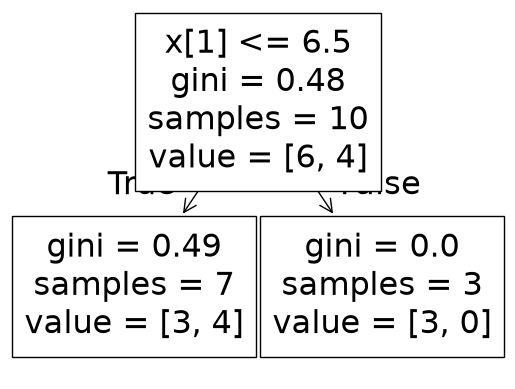

In [36]:
plot_tree(dt2)

<Axes: >

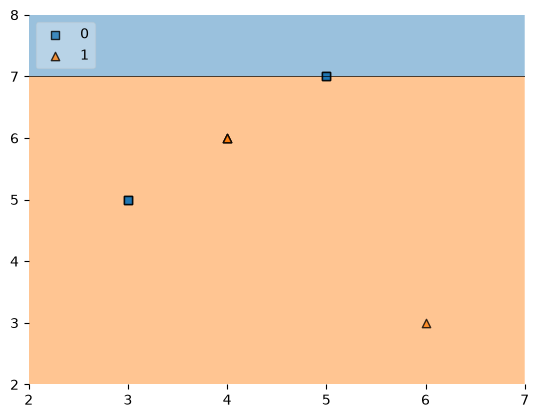

In [37]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [38]:
second_df['y_pred'] = dt2.predict(X)

In [39]:
second_df

,X1,X2,label,weights,y_pred
3,4,6,1,0.1,1
4,5,7,0,0.1,0
2,3,5,0,0.1,1
7,6,3,1,0.1,1
2,3,5,0,0.1,1
4,5,7,0,0.1,0
2,3,5,0,0.1,1
3,4,6,1,0.1,1
3,4,6,1,0.1,1
4,5,7,0,0.1,0


In [40]:
alpha2 = calculate_model_weight(0.1)

In [41]:
alpha2

np.float64(1.0986122886681098)

In [42]:
#  Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [43]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [44]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
3,4,6,1,0.1,1,0.033622
4,5,7,0,0.1,0,0.033622
2,3,5,0,0.1,1,0.297427
7,6,3,1,0.1,1,0.033622
2,3,5,0,0.1,1,0.297427
4,5,7,0,0.1,0,0.033622
2,3,5,0,0.1,1,0.297427
3,4,6,1,0.1,1,0.033622
3,4,6,1,0.1,1,0.033622
4,5,7,0,0.1,0,0.033622


In [45]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [46]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
3,4,6,1,0.1,1,0.033622,0.029816
4,5,7,0,0.1,0,0.033622,0.029816
2,3,5,0,0.1,1,0.297427,0.263762
7,6,3,1,0.1,1,0.033622,0.029816
2,3,5,0,0.1,1,0.297427,0.263762
4,5,7,0,0.1,0,0.033622,0.029816
2,3,5,0,0.1,1,0.297427,0.263762
3,4,6,1,0.1,1,0.033622,0.029816
3,4,6,1,0.1,1,0.033622,0.029816
4,5,7,0,0.1,0,0.033622,0.029816


In [47]:
second_df['nomalized_weights'].sum()

np.float64(1.0)

In [48]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
3,4,6,1,0.1,1,0.029816,0.000000,0.029816
4,5,7,0,0.1,0,0.029816,0.029816,0.059632
2,3,5,0,0.1,1,0.263762,0.059632,0.323395
7,6,3,1,0.1,1,0.029816,0.323395,0.353211
2,3,5,0,0.1,1,0.263762,0.353211,0.616973
4,5,7,0,0.1,0,0.029816,0.616973,0.646789
2,3,5,0,0.1,1,0.263762,0.646789,0.910552
3,4,6,1,0.1,1,0.029816,0.910552,0.940368
3,4,6,1,0.1,1,0.029816,0.940368,0.970184
4,5,7,0,0.1,0,0.029816,0.970184,1.000000


In [49]:
index_values = create_new_dataset(second_df)

In [50]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [51]:
third_df

,X1,X2,label,weights
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1
2,3,5,0,0.1


In [52]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

<Axes: >

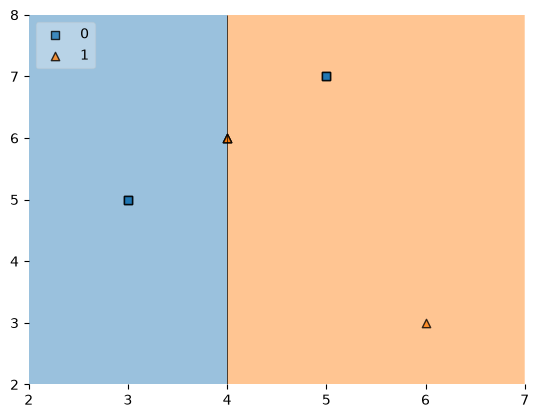

In [53]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [54]:
third_df['y_pred'] = dt3.predict(X)

In [55]:
third_df

,X1,X2,label,weights,y_pred
2,3,5,0,0.1,1
2,3,5,0,0.1,1
2,3,5,0,0.1,0
2,3,5,0,0.1,1
2,3,5,0,0.1,0
2,3,5,0,0.1,1
2,3,5,0,0.1,0
2,3,5,0,0.1,1
2,3,5,0,0.1,1
2,3,5,0,0.1,1


In [56]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [57]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


## prediction

In [58]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [59]:
dt2.predict(query)

array([1])

In [60]:
dt3.predict(query)

array([0])

In [61]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [62]:
np.sign(1.09)

np.float64(1.0)

In [63]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [64]:
dt2.predict(query)

array([0])

In [65]:
dt3.predict(query)

array([1])

In [66]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [67]:
np.sign(-0.25)

np.float64(-1.0)